In [1]:
import pandas as pd
import plotly.express as px

# Load dataset (make sure file is in same folder as notebook)
df = pd.read_csv('world_happiness_2023.csv')

# Display first rows
df.head()

,Country name,Regional indicator,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,Western Europe,7.804,10.775,0.954,71.9,0.949,0.142,0.179
1,Denmark,Western Europe,7.586,10.933,0.954,72.7,0.931,0.168,0.234
2,Iceland,Western Europe,7.525,10.878,0.983,72.5,0.961,0.260,0.150
3,Israel,Middle East and North Africa,7.473,10.527,0.916,72.4,0.903,0.149,0.826
4,Netherlands,Western Europe,7.464,11.015,0.939,72.4,0.879,0.240,0.296


In [2]:
# Rename columns for easier use
df = df.rename(columns={
    'Country name': 'Country',
    'Regional indicator': 'Region',
    'Ladder score': 'Happiness_Score'
})

df.columns

Index(['Country', 'Region', 'Happiness_Score', 'Logged GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

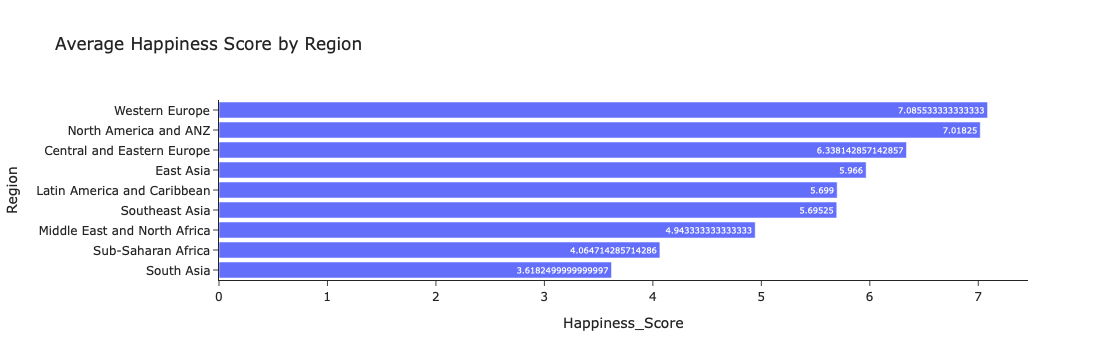

In [3]:
# Group by Region and calculate average
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))

# Plot
fig1 = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h',
    title='Average Happiness Score by Region',
    text='Happiness_Score'
)

fig1.update_layout(template='simple_white')
fig1.show()

In [ ]:
#INSIGHTS
# ->Regions like Western Europe and North America have higher happiness scores
# ->Regions like Sub-Saharan Africa have lower scores
# ->This shows strong links between economic development, healthcare, and happiness

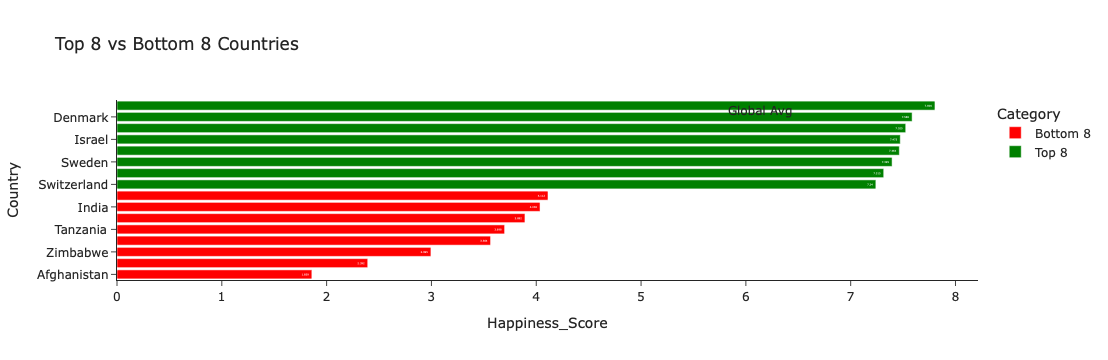

In [4]:
# Top 8 happiest countries
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Category'] = 'Top 8'

# Bottom 8 countries
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Category'] = 'Bottom 8'

# Combine
combined = pd.concat([top8, bottom8]).sort_values('Happiness_Score')

# Global average
global_avg = df['Happiness_Score'].mean()

# Plot
fig2 = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    color='Category',
    orientation='h',
    title='Top 8 vs Bottom 8 Countries',
    text='Happiness_Score',
    color_discrete_map={
        'Top 8': 'green',
        'Bottom 8': 'red'
    }
)

# Add average line
fig2.add_vline(
    x=global_avg,
    line_dash="dash",
    line_color="black",
    annotation_text="Global Avg"
)

fig2.update_layout(template='simple_white')
fig2.show()

In [ ]:
#INSIGHTS
# ->Top countries score almost double compared to bottom ones
# ->Shows huge inequality in global happiness
# ->Bottom countries often face conflict, poverty, or instability

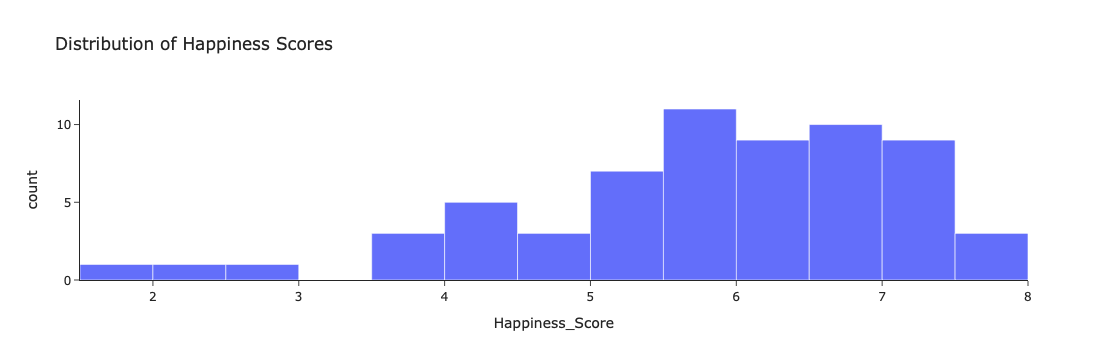

In [5]:
# Histogram
fig3 = px.histogram(
    df,
    x='Happiness_Score',
    nbins=20,
    title='Distribution of Happiness Scores'
)

fig3.update_layout(template='simple_white')
fig3.show()

In [ ]:
#INSIGHTS
# ->Most countries fall in the mid-range happiness scores
# ->Very few are extremely high or low
# ->Distribution is close to normal (bell-shaped)